In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
Data = pd.read_csv("data.csv") # reading a dataset
Data.sample(10) # showing random 10 data of a dataset

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
2821,"2 BHK Flat for Rent in Sector 9 Rohini, New Delhi",Sector 9 Rohini,New Delhi,900.0,2,2,0,Semi-Furnished,25.0,22500.0
7463,2 BHK House for Rent in Paschim Vihar New Delhi,Paschim Vihar,New Delhi,1000.0,2,1,0,Unfurnished,25.0,25000.0
1513,"2 BHK Flat for Rent in Mira Road Area, Mumbai",Mira Road,Mumbai,800.0,2,2,0,Unfurnished,31.0,25000.0
7576,"2 BHK Flat for Rent in Abbigere, Bangalore",Abbigere,Bangalore,1144.0,2,2,0,Unfurnished,27.0,31000.0
949,1 BHK House for Rent in Mahipalpur New Delhi,Mahipalpur,New Delhi,100.0,1,1,0,Semi-Furnished,80.0,8000.0
3742,"2 BHK Flat for Rent in Sector 5 Rohini, New Delhi",Sector 5 Rohini,New Delhi,52.0,2,2,0,Furnished,481.0,25000.0
3704,3 BHK Flat for Rent in Shree Ganesh Apartments...,Patparganj,New Delhi,1400.0,3,3,2,Semi-Furnished,36.0,50000.0
1559,3 BHK Flat for Rent in Bhoslenagar Ashok Nagar...,Bhoslenagar Ashok Naga,Pune,1200.0,3,3,3,Unfurnished,35.0,42000.0
2619,2 BHK House for Rent in Konanakunte Bangalore,Konanakunte,Bangalore,1200.0,2,2,0,Semi-Furnished,21.0,25000.0
4629,"3 BHK Flat for Rent in Chunabhatti, Mumbai",Chunabhatti,Mumbai,950.0,3,3,0,Unfurnished,116.0,110000.0


In [14]:
Data.shape  # showing total rows and columns of a dataset.

(7691, 10)

In [8]:
Data.info() # showing information about a dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 601.0+ KB


In [10]:
Data.isnull().sum() # Calculating total null entries in a dataset for each column.

,0
house_type,0
locality,0
city,0
area,0
beds,0
bathrooms,0
balconies,0
furnishing,0
area_rate,0
rent,0


In [11]:
Data.duplicated().sum() # Calculating duplicated values of a dataset.

np.int64(0)

In [15]:
Data = Data.dropna(subset=["bathrooms"]) # this will drop your null values from ur dataset for that specific column. The complete row will be removed containing null values.

In [42]:
cat_col = Data.select_dtypes(include= "object").columns # to retrieve the columns as per datatype from a dataset.
num_col = Data.select_dtypes(include= ["int64","float64"]).columns
cat_col, num_col

(Index(['house_type', 'locality', 'city', 'furnishing'], dtype='object'),
 Index(['area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent'], dtype='object'))

In [25]:
median_col = Data["bathrooms"].median() # Calculating the median of the specific column and it should be containing numerical values only.
median_col

2.0

In [26]:
Data['bathrooms'] = Data['bathrooms'].fillna(median_col) # this removes all the null values for the specific column and doesn't changes the shape of a dataset.

In [28]:
mode_val = Data["furnishing"].mode()[0]
mode_val

'Semi-Furnished'

In [29]:
Data["furnishing"] = Data["furnishing"].fillna(mode_val)

In [31]:
# For Filling missing values if there are any in a dataset
for col in num_col:
  median_col = Data[col].median()
  Data[col] = Data[col].fillna(median_col)

for col in cat_col:
  mode_val = Data[col].mode()[0]
  Data['furnishing'] = Data[col].fillna(mode_val)

# if categories are euqal to the number of rows, drop that column.

In [43]:
for col in cat_col:
  print(f"Unique Categories in {col} are:")
  print(Data[col].value_counts())
  print("="*80+'\n')

Unique Categories in house_type are:
house_type
3 BHK Flat for Rent in Whitefield, Bangalore                          28
3 BHK Flat for Rent in Sarjapur Road, Bangalore                       24
3 BHK Flat for Rent in Hebbal, Bangalore                              24
3 BHK Flat for Rent in Oberoi Sky City, Borivali East, Mumbai         20
1 BHK Flat for Rent in Hadapsar, Pune                                 19
                                                                      ..
3 BHK Flat for Rent in Radha Madhav Vrindavan, Wardha Road, Nagpur     1
3 BHK House for Rent in Cambridge Layout, Jogupalya Bangalore          1
3 BHK House for Rent in Dhanori Lohegaon Road Pune                     1
2 BHK Flat for Rent in Kalpataru Regency I II, Kalyani Nagar, Pune     1
2 BHK Flat for Rent in IGNOU Main Road, New Delhi                      1
Name: count, Length: 5467, dtype: int64

Unique Categories in locality are:
locality
Hadapsar               106
Kharadi                 98
Wagholi   

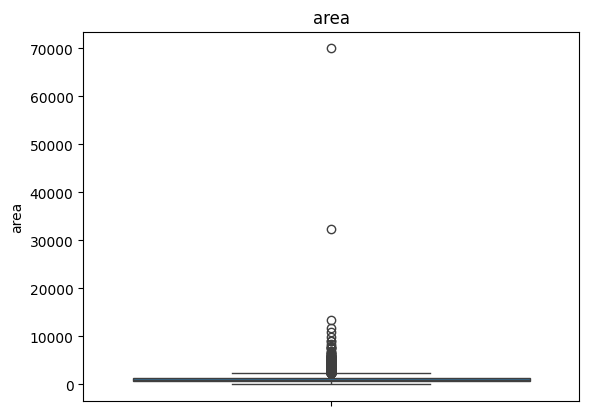

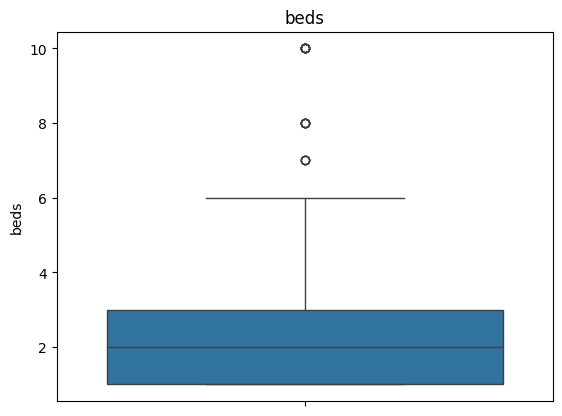

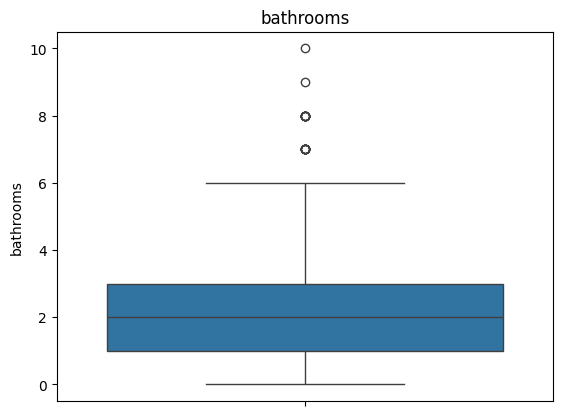

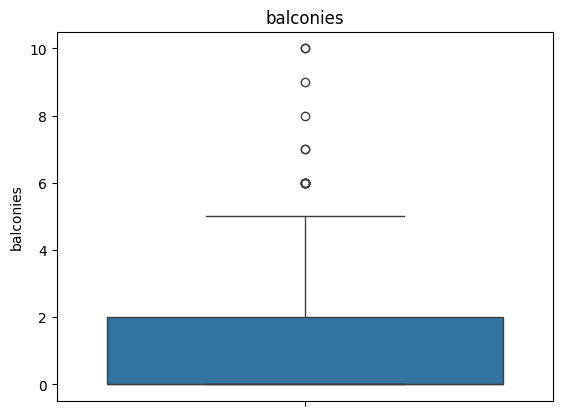

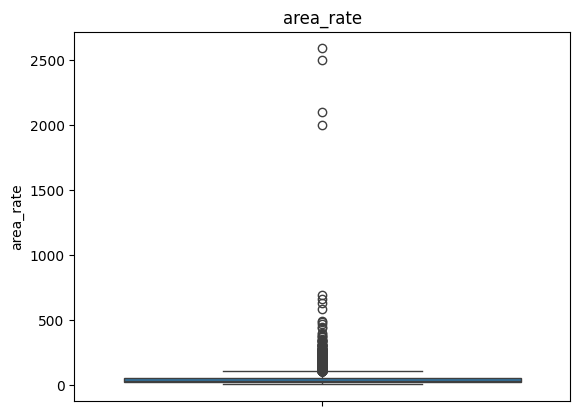

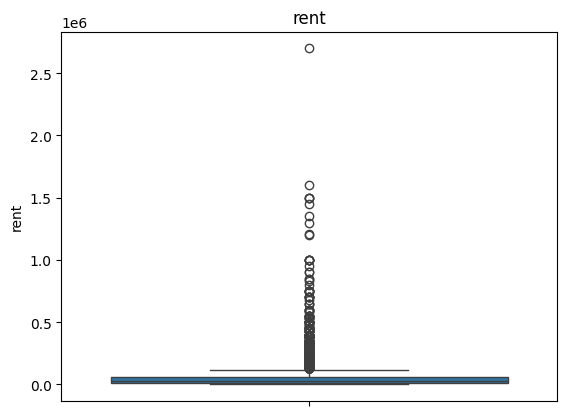

In [46]:
for col in num_col:
  sns.boxplot(Data[col])
  plt.title(col)
  plt.show()